In [2]:
import torch
import os

In [6]:
base_path="/Users/ggs/Desktop/Distacchi-Rigonf"
for directory in os.listdir(base_path):
    dir_path = os.path.join(base_path, directory)
    if not os.path.isdir(dir_path):  
        continue  
    for file in os.listdir(dir_path):
        if file.endswith(".jpg"):
            old_path = os.path.join(dir_path, file)
            new_path = os.path.join(dir_path, file.split("_")[-1])
            os.rename(old_path, new_path)

In [3]:
image = torch.load("./images-and-masks/torch-data/data/data_0")

In [9]:
import torchvision
resizer = torchvision.transforms.Resize((
    10482,10381
))

In [11]:
big_image = resizer(image)

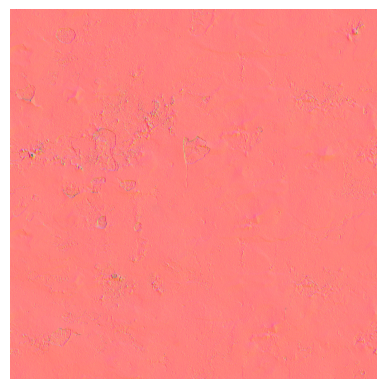

In [34]:
# show big_image as image
import matplotlib.pyplot as plt
plt.imshow(big_image.permute(1, 2, 0)[:,:,:3].cpu().numpy())
plt.axis('off')
plt.show()

In [ ]:
import torch
import math

def get_sliding_windows(image, window_size=1024):
    """
    Extract overlapping sliding windows from an image tensor.
    
    Args:
        image: torch.Tensor of shape (channels, height, width)
        window_size: int, size of square windows (default 1024)
    
    Returns:
        windows: list of torch.Tensor, each of shape (channels, window_size, window_size)
        positions: list of tuples (y, x) indicating top-left corner of each window
        grid_shape: tuple (num_windows_h, num_windows_w)
        strides: tuple (stride_h, stride_w)
    """
    channels, height, width = image.shape
    
    # Calculate number of windows needed in each dimension
    num_windows_h = math.ceil(height / window_size)
    num_windows_w = math.ceil(width / window_size)
    
    # Calculate stride for each dimension
    if num_windows_h > 1:
        stride_h = (height - window_size) / (num_windows_h - 1)
    else:
        stride_h = 0
    
    if num_windows_w > 1:
        stride_w = (width - window_size) / (num_windows_w - 1)
    else:
        stride_w = 0
    
    windows = []
    positions = []
    
    for i in range(num_windows_h):
        for j in range(num_windows_w):
            # Calculate top-left position
            y = int(round(i * stride_h))
            x = int(round(j * stride_w))
            
            # Ensure we don't go out of bounds (due to rounding)
            y = min(y, height - window_size)
            x = min(x, width - window_size)
            
            # Extract window
            window = image[:, y:y+window_size, x:x+window_size]
            
            windows.append(window)
            positions.append((y, x))
    
    return windows, positions

def reconstruct_from_windows(windows, positions, original_shape, window_size=1024):
    """
    Reconstruct the original image from overlapping windows using weighted averaging.
    
    Args:
        windows: list of torch.Tensor, each of shape (channels, window_size, window_size)
        positions: list of tuples (y, x) indicating top-left corner of each window
        original_shape: tuple (channels, height, width) of the original image
        window_size: int, size of square windows (default 1024)
    
    Returns:
        reconstructed: torch.Tensor of shape (channels, height, width)
    """
    channels, height, width = original_shape
    
    # Initialize output tensor and weight matrix
    reconstructed = torch.zeros(original_shape, dtype=windows[0].dtype, device=windows[0].device)
    weights = torch.zeros((height, width), dtype=torch.float32, device=windows[0].device)
    
    # Add each window to the reconstruction with weights
    for window, (y, x) in zip(windows, positions):
        # Add window content
        reconstructed[:, y:y+window_size, x:x+window_size] = window
        
        # # Add weight (count how many windows contribute to each pixel)
        # weights[y:y+window_size, x:x+window_size] += 1.0
    
    
    return reconstructed

In [20]:
big_image.shape

torch.Size([7, 10482, 10381])

In [ ]:
windows, positions = get_sliding_windows(big_image, window_size=1024)

In [31]:
reconstructed = reconstruct_from_windows(windows, positions, big_image.shape, window_size=1024)

In [32]:
reconstructed.shape

torch.Size([7, 10482, 10381])